In [1]:
import os, sys
os.chdir("..")
sys.path.insert(0, os.getcwd())

In [63]:
import umap
import numpy as np 
import matplotlib.pyplot as plt 


In [ ]:
from src.preprocess import predict_entites,compute_density_semantic,compute_average_sematic_score,load_gliner_model
from src.utils import load_json_file,load_pdf_file,load_toml_file
from sentence_transformers import SentenceTransformer


In [ ]:
text1 = load_pdf_file("text/Depression_A_Review_of_its_Definition.pdf")
text2 = load_pdf_file("text/depression.pdf")
model_configs = load_toml_file("configs/models/qwen2-5_config.toml")
res = load_json_file("res/test.json")

In [ ]:
model,labels,threshold_score = load_gliner_model("configs/models/gliner-qwen-0.5B-v1.0.toml")

In [10]:
entities1 = predict_entites(text1,model,labels,threshold_score)
entities2 = predict_entites(text2,model,labels,threshold_score)

c:\Users\estev\Documents\Stage_LIRMM\MedOnto\myenv\Lib\site-packages\gliner\data_processing\processor.py:427: UserWarning: Sentence of length 2113 has been truncated to 1024
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
c:\Users\estev\Documents\Stage_LIRMM\MedOnto\myenv\Lib\site-packages\gliner\data_processing\processor.py:427: UserWarning: Sentence of length 3268 has been truncated to 1024
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]


In [11]:
print(f"Depression_A_Review_of_its_Definition.pdf density: {compute_density_semantic(entities1,text1)}")
print(f"Depression_A_Review_of_its_Definition.pdf density without stopwords: {compute_density_semantic(entities1,text1,True)}")
print(f"Depression_A_Review_of_its_Definition.pdf average score: {compute_average_sematic_score(entities1)}")

print(f"depression.pdf density: {compute_density_semantic(entities2,text2)}")
print(f"depression.pdf density: {compute_density_semantic(entities2,text2,True)}")
print(f"depression.pdf average score: {compute_average_sematic_score(entities2)}")


Depression_A_Review_of_its_Definition.pdf density: 0.10618932038834951
Depression_A_Review_of_its_Definition.pdf density without stopwords: 0.16859344894026976
Depression_A_Review_of_its_Definition.pdf average score: 0.19709784831319538
depression.pdf density: 0.06723309937199852
depression.pdf density: 0.10712183637433785
depression.pdf average score: 0.18919477296563295


In [ ]:
res_text1 = res['text/depression.pdf']
res_text2 = res['text/Depression_A_Review_of_its_Definition.pdf']

subject1 = {triplet["subject"] for triplet in res_text1}
subject2 = {triplet["subject"] for triplet in res_text2}

object1 = {triplet["object"] for triplet in res_text1}
object2 = {triplet["object"] for triplet in res_text2}


concepts1 = list(subject1 | object1)
concepts2 = list(subject1 | object2)

In [49]:
st = SentenceTransformer(model_configs.pop("model_id"))
emb1 = st.encode(concepts1, normalize_embeddings=True)
emb2 = st.encode(concepts2, normalize_embeddings=True)

Loading weights: 100%|██████████| 338/338 [00:00<00:00, 6061.96it/s]


In [53]:
emb = np.concatenate([emb1, emb2], axis=0)
reducer = umap.UMAP(
    n_components=2,
    metric="cosine",     
    n_neighbors=15,
    min_dist=0.1,
    random_state=42,     
).fit(emb)

c:\Users\estev\Documents\Stage_LIRMM\MedOnto\myenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [55]:
emb1 = reducer.transform(emb1)
emb2 = reducer.transform(emb2)

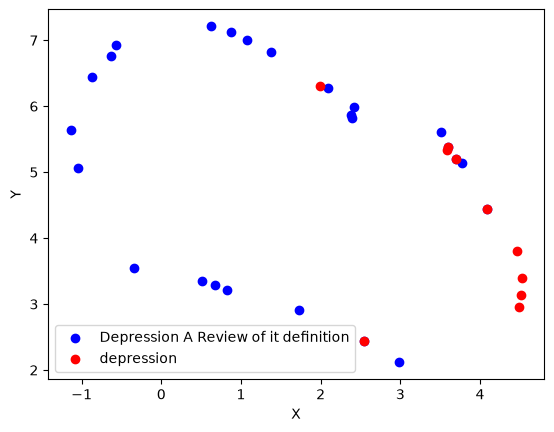

In [64]:
plt.scatter(emb1[:,0], emb1[:,1], color="blue", label="Depression A Review of it definition")
plt.scatter(emb2[:,0], emb2[:,1], color="red", label="depression")

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()